# 目的

1. **クラス不均衡の把握** → 損失関数・サンプリング戦略を決定
2. **音声ファイルの特性把握** → ウィンドウ戦略・パディング量を決定
3. **Secondly lablelsの活用可能性確認** → soft labelの重みを決定
4. **音声の視覚的確認** → スペクトログラムパラメータを決定

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
from IPython.display import Audio, display
from collections import Counter

warnings.filterwarnings('ignore')
COMP = '/kaggle/input/competitions/birdclef-2026'
SR   = 32000
print('Data path:', COMP)
print('Files:', os.listdir(COMP))


Data path: /kaggle/input/competitions/birdclef-2026
Files: ['sample_submission.csv', 'taxonomy.csv', 'train_audio', 'train_soundscapes_labels.csv', 'train_soundscapes', 'train.csv', 'recording_location.txt', 'test_soundscapes']


## 1. メタデータの基本確認

In [2]:
def show_input_tree():
    for root, dirs, files in os.walk('/kaggle/input'):
        level = root.replace('/kaggle/input', '').count(os.sep)
        if level < 4:
            indent = '  ' * level
            print(f'{indent}{os.path.basename(root)}/')
            if level == 3:
                print(f'{indent}  ... ({len(files)} files)')

show_input_tree()

input/
  datasets/
    takuya23/
      birdclef-2026-code/
        ... (0 files)
  competitions/
    birdclef-2026/
      train_audio/
        ... (0 files)
      train_soundscapes/
        ... (10658 files)
      test_soundscapes/
        ... (1 files)
  notebooks/
    takuya23/
      notebook8b449683e6/
        ... (0 files)


In [3]:
df = pd.read_csv(f'{COMP}/train.csv')
print(f'行数:{len(df):,} | 列数:{len(df.columns)}')
print('\nカラム一覧:')
print(df.dtypes)
df.head()

è¡æ°:35,549 | åæ°:15

ã«ã©ã ä¸è¦§:
primary_label        object
secondary_labels     object
type                 object
latitude            float64
longitude           float64
scientific_name      object
common_name          object
class_name           object
inat_taxon_id         int64
author               object
license              object
rating              float64
url                  object
filename             object
collection           object
dtype: object


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [4]:
# 欠損値の確認
miss = df.isnull().sum()
miss = miss[miss > 0]

## 2. クラス分類

In [5]:
counts = df['primary_label'].value_counts()
n_cls  = len(counts)

print(f'総クラス数: {n_cls}')
print(f'合計サンプル数: {len(df):,}')
print(f'\n--- サンプル数の統計 ---')
print(f'最小: {counts.min()}')
print(f'中央値: {counts.median():.0f}')
print(f'平均: {counts.mean():.1f}')
print(f'最大: {counts.max()}')
print(f'\n5サンプル以下のクラス数: {(counts <= 5).sum()}')
print(f'20サンプル以下のクラス数: {(counts <= 20).sum()}')
print(f'\n最少サンプル上位10種:')
print(counts.tail(10).to_string())

ç·ã¯ã©ã¹æ°: 206
åè¨ãµã³ãã«æ°: 35,549

--- ãµã³ãã«æ°ã®çµ±è¨ ---
æå°: 1
ä¸­å¤®å¤: 125
å¹³å: 172.6
æå¤§: 499

5ãµã³ãã«ä»¥ä¸ã®ã¯ã©ã¹æ°: 18
20ãµã³ãã«ä»¥ä¸ã®ã¯ã©ã¹æ°: 36

æå°ãµã³ãã«ä¸ä½10ç¨®:
primary_label
74580      3
555123     3
sptnig1    3
24321      2
70711      2
209233     2
516975     1
23724      1
116570     1
23150      1


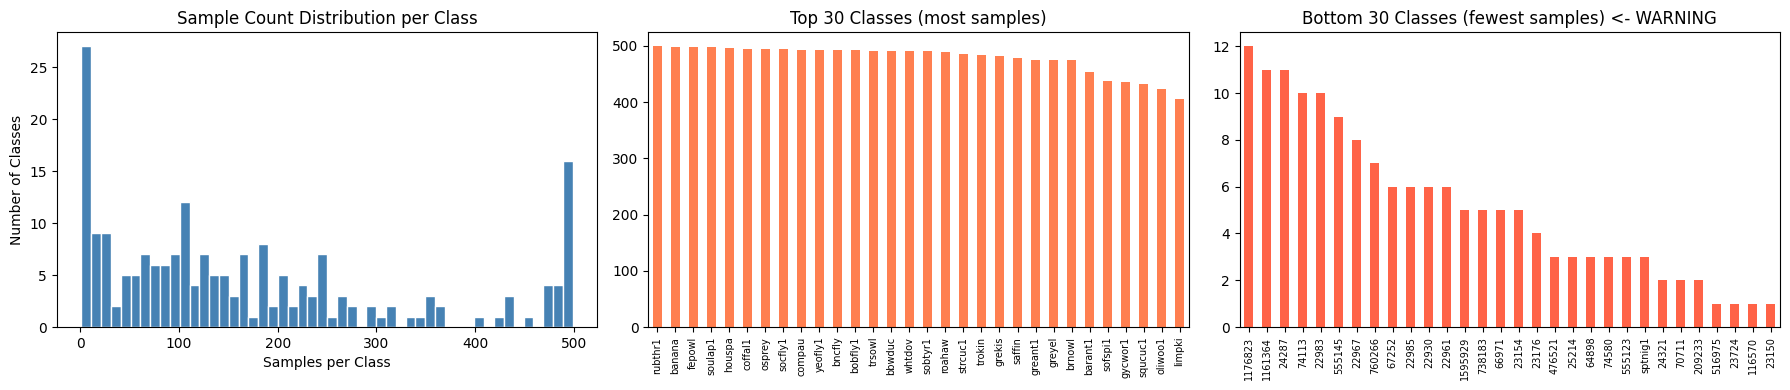


ä¸åè¡¡ç (max/min): 499.0x
â Focal Loss ãæå¹ãªçç±ãããã


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ヒストグラム
axes[0].hist(counts.values, bins=50, edgecolor='white', color='steelblue')
axes[0].set_xlabel('Samples per Class')
axes[0].set_ylabel('Number of Classes')
axes[0].set_title('Sample Count Distribution per Class')

# 上位30クラス
counts.head(30).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 30 Classes (most samples)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)

# 下位30クラス
counts.tail(30).plot(kind='bar', ax=axes[2], color='tomato')
axes[2].set_title('Bottom 30 Classes (fewest samples) <- WARNING')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.show()

# 不均衡率
imbalance_ratio = counts.max() / counts.min()
print(f'\n不均衡率 (max/min): {imbalance_ratio:.1f}x')
print('→ Focal Loss が有効な理由がわかる')

## 3. Secondary Labels の確認

In [7]:
import ast

def parse_secondary(raw):
    if pd.isna(raw) or str(raw).strip() in ('[]', ''):
        return []
    try:
        return ast.literal_eval(str(raw))
    except:
        return []

df['sec_parsed'] = df['secondary_labels'].apply(parse_secondary)
df['n_secondary'] = df['sec_parsed'].apply(len)

has_sec = (df['n_secondary'] > 0).sum()
print(f'secondary labels を持つ行数: {has_sec:,} / {len(df):,} ({has_sec/len(df)*100:.1f}%)')
print(f'\nsecondary label 数の分布:')
print(df['n_secondary'].value_counts().sort_index().head(10).to_string())

# secondary として出現頻度が高い種
all_sec = [s for lst in df['sec_parsed'] for s in lst]
print(f'\n合計 secondary label 数: {len(all_sec):,}')
sec_counts = pd.Series(Counter(all_sec)).sort_values(ascending=False)
print('\nSecondary として頻出の上位20種:')
print(sec_counts.head(20).to_string())

secondary labels ãæã¤è¡æ°: 4,372 / 35,549 (12.3%)

secondary label æ°ã®åå¸:
n_secondary
0    31177
1     2623
2     1049
3      379
4      169
5       87
6       35
7       11
8       12
9        1

åè¨ secondary label æ°: 7,431

Secondary ã¨ãã¦é »åºã®ä¸ä½20ç¨®:
grekis     624
whtdov     468
undtin1    315
yecpar     226
rufhor2    225
saffin     183
picpig2    172
trokin     171
soulap1    154
grasal3    151
chobla1    150
rubthr1    128
scadov1    127
banana     118
fepowl     104
barant1     96
thlwre1     95
greant1     94
yebela1     88
bobfly1     84


## 4. 音声ファイルの特性

ãµã³ããªã³ã°æ°: 100 ä»¶ (ã¨ã©ã¼: 0 ä»¶)

é³å£°é·ã®çµ±è¨ (ç§):
  æå°: 0.1s
  ä¸­å¤®å¤: 20.0s
  å¹³å: 32.8s
  æå¤§: 260.9s

  5s ä»¥ä¸: 12 ä»¶ â zero-padding ãå¿è¦
  5s ã¡ããã©: 0 ä»¶
  5s è¶: 88 ä»¶


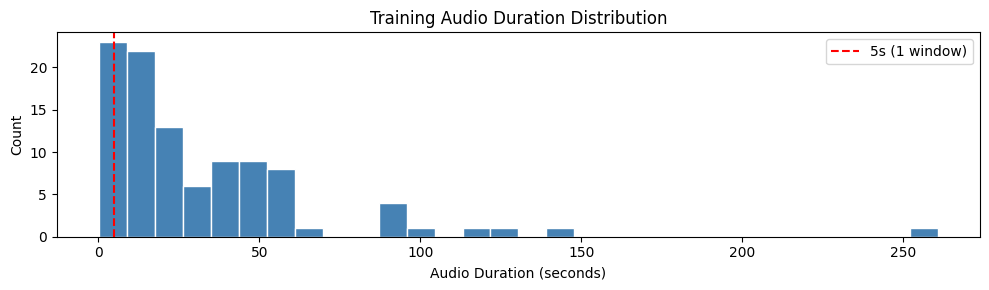

In [8]:
# ランダムサンプリングして音声ファイルの長さを計測
# (全ファイルは時間がかかるので100件)
sample_df = df.sample(min(100, len(df)), random_state=42)
durations = []
errors    = []

for _, row in sample_df.iterrows():
    path = os.path.join(COMP, 'train_audio', row['filename'])
    if not os.path.exists(path):
        errors.append(path)
        continue
    try:
        dur = librosa.get_duration(path=path)
        durations.append(dur)
    except:
        errors.append(path)

dur_arr = np.array(durations)
print(f'サンプリング数: {len(durations)} 件 (エラー: {len(errors)} 件)')
print(f'\n音声長の統計 (秒):')
print(f'  最小: {dur_arr.min():.1f}s')
print(f'  中央値: {np.median(dur_arr):.1f}s')
print(f'  平均: {dur_arr.mean():.1f}s')
print(f'  最大: {dur_arr.max():.1f}s')
print(f'\n  5s 以下: {(dur_arr < 5).sum()} 件 → zero-padding が必要')
print(f'  5s ちょうど: {((dur_arr >= 4.9) & (dur_arr <= 5.1)).sum()} 件')
print(f'  5s 超: {(dur_arr > 5).sum()} 件')

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(dur_arr, bins=30, edgecolor='white', color='steelblue')
ax.axvline(5, color='red', linestyle='--', label='5s (1 window)')
ax.set_xlabel('Audio Duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Training Audio Duration Distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 5. メルスペクトログラムの視覚確認

In [ ]:
# サンプル音声を複数種で可視化
# (よく出現する種 + 少ないサンプルの種 を比較)
top_species    = df['primary_label'].value_counts().head(3).index.tolist()
bottom_species = df['primary_label'].value_counts().tail(3).index.tolist()
sample_species = top_species + bottom_species

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.3)

for i, sp in enumerate(sample_species):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    row = df[df['primary_label'] == sp].iloc[0]
    path = os.path.join(COMP, 'train_audio', row['filename'])
    
    try:
        y, _ = librosa.load(path, sr=SR, duration=5.0, mono=True)
        if len(y) < SR * 5:
            y = np.pad(y, (0, SR * 5 - len(y)))
        mel = librosa.feature.melspectrogram(
            y=y, sr=SR, n_mels=128, n_fft=2048, hop_length=512, fmin=50, fmax=16000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, sr=SR, hop_length=512, x_axis='time',
                                  y_axis='mel', fmin=50, fmax=16000, ax=ax)
        label_type = '(many)' if sp in top_species else '(few)'
        n_samp = df[df['primary_label'] == sp].shape[0]
        ax.set_title(f'{sp} {label_type}\nn={n_samp}', fontsize=9)
    except Exception as e:
        ax.set_title(f'{sp}\n(読み込み失敗)', fontsize=9)
        ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha='center')

plt.suptitle('Mel Spectrogram Examples
(top: high-sample / bottom: low-sample species)', y=1.02)', y=1.02)
plt.show()

## 6. テストサウンドスケープの確認

In [10]:
test_dir   = f'{COMP}/test_soundscapes'
test_files = sorted(glob.glob(f'{test_dir}/*.ogg'))
print(f'テストファイル数: {len(test_files)}')

if test_files:
    test_durs = []
    for fp in test_files[:20]:   # 最大20件で推定
        try:
            test_durs.append(librosa.get_duration(path=fp))
        except:
            pass
    test_durs = np.array(test_durs)
    print(f'\nテスト音声長 (最大20件サンプル):')
    print(f'  最小: {test_durs.min():.0f}s')
    print(f'  最大: {test_durs.max():.0f}s')
    print(f'  平均: {test_durs.mean():.0f}s')

    total_windows = sum(int(d / 5) for d in test_durs) * (len(test_files) // max(len(test_durs), 1))
    print(f'\n推定総ウィンドウ数 (overlap なし): ~{total_windows:,}')
    print(f'推定総ウィンドウ数 (2.5s overlap): ~{total_windows * 2:,}')

ãã¹ããã¡ã¤ã«æ°: 0


In [ ]:
# サンプル音声を複数種で可視化
# (よく出現する種 + 少ないサンプルの種 を比較)
top_species    = df['primary_label'].value_counts().head(3).index.tolist()
bottom_species = df['primary_label'].value_counts().tail(3).index.tolist()
sample_species = top_species + bottom_species

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.3)

for i, sp in enumerate(sample_species):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    row = df[df['primary_label'] == sp].iloc[0]
    path = os.path.join(COMP, 'train_audio', row['filename'])
    
    try:
        y, _ = librosa.load(path, sr=SR, duration=5.0, mono=True)
        if len(y) < SR * 5:
            y = np.pad(y, (0, SR * 5 - len(y)))
        mel = librosa.feature.melspectrogram(
            y=y, sr=SR, n_mels=128, n_fft=2048, hop_length=512, fmin=50, fmax=16000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, sr=SR, hop_length=512, x_axis='time',
                                  y_axis='mel', fmin=50, fmax=16000, ax=ax)
        label_type = '(many)' if sp in top_species else '(few)'
        n_samp = df[df['primary_label'] == sp].shape[0]
        ax.set_title(f'{sp} {label_type}\nn={n_samp}', fontsize=9)
    except Exception as e:
        ax.set_title(f'{sp}\n(読み込み失敗)', fontsize=9)
        ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha='center')

plt.suptitle('Mel Spectrogram Examples
(top: high-sample / bottom: low-sample species)', y=1.02)', y=1.02)
plt.show()

## 7. Sample Submission の確認

In [12]:
sub = pd.read_csv(f'{COMP}/sample_submission.csv')
species_cols = [c for c in sub.columns if c != 'row_id']
print(f'提出行数: {len(sub):,}')
print(f'種列数 (= 分類クラス数): {len(species_cols)}')
print(f'\nrow_id の例:')
print(sub['row_id'].head(5).tolist())

# row_id のパターン確認
parts = sub['row_id'].str.rsplit('_', n=1, expand=True)
parts.columns = ['filename_stem', 'second']
seconds = parts['second'].astype(int)
print(f'\n秒数の種類: {sorted(seconds.unique())[:20]} ...')
print(f'→ {seconds.min()}s 〜 {seconds.max()}s まで、5s 刻みで評価される')

æåºè¡æ°: 3
ç¨®åæ° (= åé¡ã¯ã©ã¹æ°): 234

row_id ã®ä¾:
['BC2026_Test_0001_S05_20250227_010002_5', 'BC2026_Test_0001_S05_20250227_010002_10', 'BC2026_Test_0001_S05_20250227_010002_15']

ç§æ°ã®ç¨®é¡: [np.int64(5), np.int64(10), np.int64(15)] ...
â 5s ã 15s ã¾ã§ã5s å»ã¿ã§è©ä¾¡ããã


In [13]:
# 学習データの種 vs 提出要求の種の対応確認
train_species = set(df['primary_label'].unique())
sub_species   = set(species_cols)

only_in_train = train_species - sub_species
only_in_sub   = sub_species   - train_species
in_both       = train_species & sub_species

print(f'学習データの種数: {len(train_species)}')
print(f'提出要求の種数:   {len(sub_species)}')
print(f'両方にある種数:   {len(in_both)}')
print(f'学習のみにある種: {len(only_in_train)} (提出不要)')
print(f'提出のみにある種: {len(only_in_sub)} ← 学習データがない!')

if only_in_sub:
    print(f'\n提出要求だが学習データなし (先頭10種):')
    print(sorted(only_in_sub)[:10])
    print('→ これらの種は予測スコアが常に 0.0 になる (Padded cmAP への影響を確認すること)')

å­¦ç¿ãã¼ã¿ã®ç¨®æ°: 206
æåºè¦æ±ã®ç¨®æ°:   234
ä¸¡æ¹ã«ããç¨®æ°:   206
å­¦ç¿ã®ã¿ã«ããç¨®: 0 (æåºä¸è¦)
æåºã®ã¿ã«ããç¨®: 28 â å­¦ç¿ãã¼ã¿ããªã!

æåºè¦æ±ã ãå­¦ç¿ãã¼ã¿ãªã (åé ­10ç¨®):
['1491113', '25073', '47158son01', '47158son02', '47158son03', '47158son04', '47158son05', '47158son06', '47158son07', '47158son08']
â ãããã®ç¨®ã¯äºæ¸¬ã¹ã³ã¢ãå¸¸ã« 0.0 ã«ãªã (Padded cmAP ã¸ã®å½±é¿ãç¢ºèªãããã¨)
